# GSN-ISEM radial functions

The public solver constructs the generalized Sasaki-Nakamura function \(X\) directly. The Teukolsky \(R\) and source-adapted \(Y\) functions below are numerical wrappers around the same GSN-ISEM route. The \(Y\) wrapper is available for \(s=-2\) with IN and \(s=+2\) with UP.


In [ ]:
using GeneralizedSasakiNakamura
using Plots, LaTeXStrings


In [ ]:
# A branch supported by all three X, R, and Y interfaces.
s = -2
l = 2
m = 2
a = 0.7
omega = 0.25
bc = IN

# NOTE: julia uses 'just-ahead-of-time' compilation. Calling this the first time in each session will take some time
R = Teukolsky_radial(s, l, m, a, omega, bc, rsin, rsout; method="Riccati")

TeukolskyRadialFunction(
    mode = Mode(s = -2, l = 2, m = 2, a = 0.7, omega = 0.25, lambda = 2.8411233382314958),
    boundary_condition = UP,
    transmission_amplitude = 1.0 + 0.0im,
    incidence_amplitude = 205.05589286537608 - 60.33321745548875im,
    reflection_amplitude = -174.99152022890522 + 341.7170416985376im,
    normalization_convention = UNIT_TEUKOLSKY_TRANS
)

In [ ]:
# Set up a grid of the tortoise coordinate rs
rsgrid = collect(-30:1:300) # Does not have to be within [rsin, rsout]
# Set up a grid of the Boyer-Lindquist r coordinate
# Convert from rsgrid using r_from_rstar(a, rs)
rgrid = [r_from_rstar(a, rs) for rs in rsgrid];

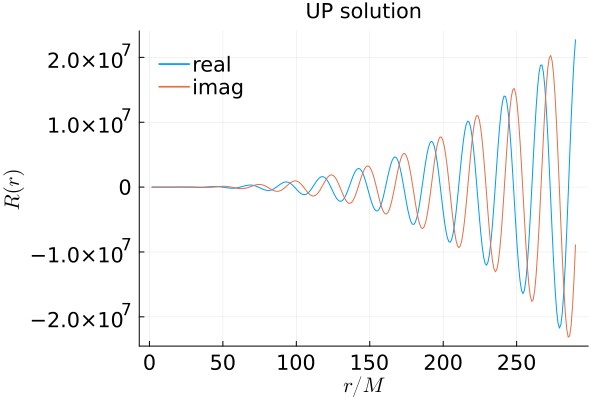

In [5]:
# Visualize the Teukolsky function

X_values = getindex.(x_state, 1)
dXdrstar_values = getindex.(x_state, 2)
R_values = getindex.(r_state, 1)
Y_values = getindex.(y_state, 1)


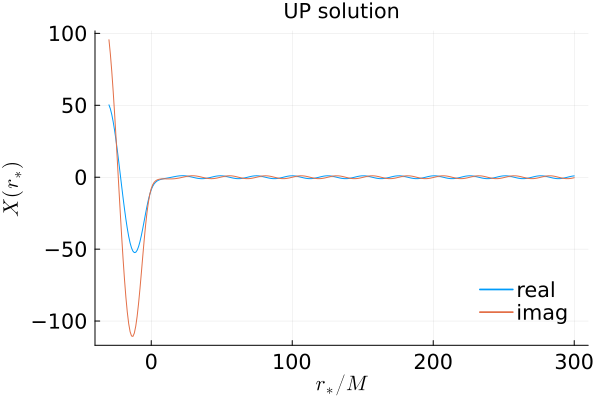

In [ ]:
pX = plot(rstar_grid, [real.(X_values) imag.(X_values)];
    label = ["real" "imag"], xlabel = L"r_*/M", ylabel = L"X(r_*)",
    title = "Direct GSN solution", legend = :topright)

pR = plot(r_grid, [real.(R_values) imag.(R_values)];
    label = ["real" "imag"], xlabel = L"r/M", ylabel = L"R(r)",
    title = "Teukolsky wrapper", legend = :topright)

pY = plot(r_grid, [real.(Y_values) imag.(Y_values)];
    label = ["real" "imag"], xlabel = L"r/M", ylabel = L"Y(r)",
    title = "Source-adapted wrapper", legend = :topright)

plot(pX, pR, pY; layout = (3, 1), size = (900, 960))


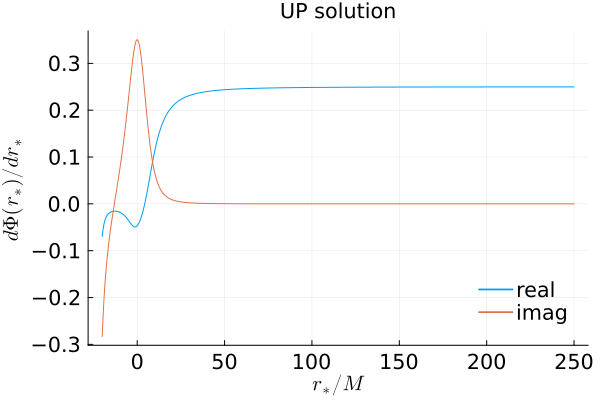

In [ ]:
plot(rstar_grid, [real.(dXdrstar_values) imag.(dXdrstar_values)];
    label = ["real" "imag"], xlabel = L"r_*/M", ylabel = L"dX/dr_*",
    title = "Derivative returned with the same series evaluation",
    legend = :topright, size = (900, 320))


In [ ]:
(;
    method = X.method,
    frequency_regime = X.numerical_GSN_solution.frequency_regime,
    spin_regime = X.numerical_GSN_solution.spin_regime,
    propagation = X.numerical_GSN_solution.propagation_representation,
    matching = X.numerical_GSN_solution.matching_representation,
    matching_x = X.numerical_GSN_solution.xm,
    patch_count = X.numerical_GSN_solution.patch_count,
    incidence_amplitude = X.incidence_amplitude,
    reflection_amplitude = X.reflection_amplitude,
)
